# GMIC — CMMD2022 Degerlendirme (Parca 9)

Bu notebook **hic egitim yapmaz** ve egitim notebook'undan bagimsizdir; yalnizca Parca 8'in
yazdigi meme seviyesi tahminleri okur. GPU gerekmez.

Uc sey uretiyor:

1. **Turetilmis deneyler** (makalenin Tablo 1'indeki varyantlar, ayri egitim gerektirmez):
   `gmic_loc` = tam modelin `y_loc`'u, `gmic_mil` = `y_mil`'i,
   `gmic_loc_random` = `gmic`'in `y_loc`'u ile `gmic_random`'in `y_mil`'inin ortalamasi.
   **Ensemble** = aramanin top-3 konfigurasyonunun ortalamasi.
2. **Belirsizlik**: her AUC icin bootstrap %95 guven araligi (2.000 tekrar, sinifa gore
   tabakali) ve **DeLong** testiyle eslesmis AUC karsilastirmasi.
3. **Alt grup kirilimi**: D1/D2, `abnormality`, yas.

Neden gerekli: D1 test kohortu 165 meme. Parca 8 tablosunda dokuz deneyin yedisi 0,70-0,78
arasinda sikisiyor ve bu bandin tamami orneklem gurultusunun icinde olabilir. Siralamaya bakip
"attention zarar veriyor" demek ile "farki olcmeye yetecek veri yok" demek arasindaki ayrimi
ancak bu testler kurar.

Ciktilar `degerlendirme/` altina yazilir.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import roc_auc_score

ORTAM = 'colab' if os.path.isdir('/content') else 'yerel'
if ORTAM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

KOK = Path('/content/drive/MyDrive/multiple_instance_classifier' if ORTAM == 'colab'
           else Path.cwd())
DEG_DIR = KOK / 'degerlendirme'
DEG_DIR.mkdir(parents=True, exist_ok=True)

with open(KOK / 'hazir' / 'config.json', encoding='utf-8') as f:
    SEED = json.load(f)['SEED']

# Deney listesi diskten kesfediliyor -- egitim notebook'undaki TAM_SIRA'ya bagimli degiliz.
EGITILEN = sorted(p.parent.name for p in KOK.glob('*/*_test_tahminler.xlsx'))
assert EGITILEN, f'{KOK} altinda test tahmini bulunamadi -- once Parca 8 kosmali'

# Ensemble uyeleri: aramanin top-3'u. gmic = 1. sira, gmic_hp2 = 2., gmic_hp3 = 3.
ENSEMBLE_UYELERI = [k for k in ['gmic', 'gmic_hp2', 'gmic_hp3'] if k in EGITILEN]
with open(KOK / 'arama' / 'secim.json', encoding='utf-8') as f:
    SECIM = json.load(f)
print(f'ortam: {ORTAM} | kok: {KOK}')
print(f'{len(EGITILEN)} deney bulundu: {", ".join(EGITILEN)}')
print(f'ensemble uyeleri: {ENSEMBLE_UYELERI}  (arama top-3 kosu {SECIM["top3_id"]}, '
      f'val AUC {[round(a, 4) for a in SECIM["top3_auc"]]})')
assert len(ENSEMBLE_UYELERI) == 3, 'ensemble icin 3 kosu gerekiyor'

Mounted at /content/drive
ortam: colab | kok: /content/drive/MyDrive/multiple_instance_classifier
9 deney bulundu: gmic, gmic_augment, gmic_ft_scratch, gmic_hp2, gmic_hp3, gmic_lowres, gmic_noattn, gmic_random, resnet22_baseline
ensemble uyeleri: ['gmic', 'gmic_hp2', 'gmic_hp3']  (arama top-3 kosu [5, 4, 10], val AUC [0.8133, 0.7767, 0.7583])


In [2]:
def tahminleri_yukle():
    """Her deneyin meme seviyesi tahminlerini tek tabloda birlestirir (meme x deney)."""
    taban, sutunlar = None, {}
    for key in EGITILEN:
        d = pd.read_excel(KOK / key / f'{key}_test_tahminler.xlsx').set_index('meme').sort_index()
        if taban is None:
            taban = d[['y_malign', 'y_benign', 'hasta', 'taraf', 'classification',
                       'abnormality', 'Age', 'subtype', 'grup']].copy()
        else:
            assert d.index.equals(taban.index), f'{key}: meme listesi farkli'
            assert (d.y_malign.to_numpy() == taban.y_malign.to_numpy()).all(), f'{key}: etiket farkli'
        sutunlar[key] = d.p_malign
        sutunlar[f'{key}__loc'] = d.p_loc_malign
        sutunlar[f'{key}__mil'] = d.p_mil_malign
    return taban.join(pd.DataFrame(sutunlar))


T = tahminleri_yukle()

# --- turetilmis deneyler: yeniden egitim yok, mevcut ciktilardan hesaplaniyor
T['gmic_loc'] = T['gmic__loc']
T['gmic_mil'] = T['gmic__mil']
T['gmic_loc_random'] = (T['gmic__loc'] + T['gmic_random__mil']) / 2
T['ensemble_top3'] = T[ENSEMBLE_UYELERI].mean(axis=1)

TURETILEN = ['gmic_loc', 'gmic_mil', 'gmic_loc_random', 'ensemble_top3']
MODELLER = EGITILEN + TURETILEN

T.to_excel(DEG_DIR / 'tahmin_matrisi.xlsx')
print(f'{len(T)} meme x {len(MODELLER)} model | {DEG_DIR / "tahmin_matrisi.xlsx"}')
print(f'  turetilen: {", ".join(TURETILEN)}')
print(f'kohort: {T.grup.value_counts().to_dict()} | malign {int(T.y_malign.sum())}/{len(T)}')

280 meme x 13 model | /content/drive/MyDrive/multiple_instance_classifier/degerlendirme/tahmin_matrisi.xlsx
  turetilen: gmic_loc, gmic_mil, gmic_loc_random, ensemble_top3
kohort: {'D1': 165, 'D2': 115} | malign 198/280


In [3]:
# --- DeLong (Sun & Xu 2014 hizli varyanti) ve bootstrap ---------------------------------
# sklearn'de yok, elle uygulaniyor; asagida roc_auc_score'a karsi dogrulaniyor.

def _midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T_ = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T_[i:j] = 0.5 * (i + j - 1) + 1     # esit degerlere ortalama sira
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T_
    return T2


def delong(y, P):
    """P: (k, n) tahmin matrisi. Doner: auc (k,), kovaryans (k, k).

    AUC'nin Mann-Whitney gosterimi uzerinden yapisal bilesenlerle (V10/V01) kovaryans.
    Eslesmis karsilastirma icin sart: ayni memelerde iki modelin tahminleri korelasyonlu,
    bagimsiz test yanlis sonuc verir.
    """
    P = np.atleast_2d(np.asarray(P, dtype=float))
    poz, neg = P[:, y == 1], P[:, y == 0]
    m, n = poz.shape[1], neg.shape[1]
    k = P.shape[0]
    tx = np.empty((k, m)); ty = np.empty((k, n)); tz = np.empty((k, m + n))
    for r in range(k):
        tx[r] = _midrank(poz[r])
        ty[r] = _midrank(neg[r])
        tz[r] = _midrank(np.concatenate([poz[r], neg[r]]))
    auc = tz[:, :m].sum(axis=1) / (m * n) - (m + 1) / (2 * n)
    v01 = (tz[:, :m] - tx) / n
    v10 = 1 - (tz[:, m:] - ty) / m
    S = np.cov(v01, ddof=1).reshape(k, k) / m + np.cov(v10, ddof=1).reshape(k, k) / n
    return auc, S


def delong_p(y, p1, p2):
    """Eslesmis AUC farki icin iki yonlu p degeri."""
    auc, S = delong(y, np.vstack([np.asarray(p1, float), np.asarray(p2, float)]))
    var = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    if var <= 0:
        return float(auc[0] - auc[1]), (0.0 if abs(auc[0] - auc[1]) > 1e-12 else 1.0)
    z = (auc[0] - auc[1]) / np.sqrt(var)
    return float(auc[0] - auc[1]), float(2 * stats.norm.sf(abs(z)))


def bootstrap_ci(y, p, n_boot=2000, tohum=SEED):
    """Sinifa gore tabakali bootstrap; %95 persentil araligi."""
    y = np.asarray(y); p = np.asarray(p, float)
    i_poz = np.flatnonzero(y == 1)
    i_neg = np.flatnonzero(y == 0)
    rng = np.random.default_rng(tohum)
    ler = np.empty(n_boot)
    for b in range(n_boot):
        idx = np.concatenate([rng.choice(i_poz, len(i_poz), replace=True),
                              rng.choice(i_neg, len(i_neg), replace=True)])
        ler[b] = roc_auc_score(y[idx], p[idx])
    return float(np.percentile(ler, 2.5)), float(np.percentile(ler, 97.5))


# --- dogrulama: DeLong elle yazildi, sessizce yanlis olmasin
_rng = np.random.default_rng(0)
_y = np.r_[np.ones(60), np.zeros(90)].astype(int)
_p1 = np.r_[_rng.normal(1.0, 1, 60), _rng.normal(0, 1, 90)]
_p2 = np.r_[_rng.normal(0.3, 1, 60), _rng.normal(0, 1, 90)]

_a, _S = delong(_y, np.vstack([_p1, _p2]))
assert abs(_a[0] - roc_auc_score(_y, _p1)) < 1e-9
assert abs(_a[1] - roc_auc_score(_y, _p2)) < 1e-9
print(f'DeLong AUC = roc_auc_score: {_a[0]:.6f} / {_a[1]:.6f}')

_d, _pv = delong_p(_y, _p1, _p2)
_d2, _pv2 = delong_p(_y, _p2, _p1)
assert abs(_pv - _pv2) < 1e-12 and abs(_d + _d2) < 1e-12, 'simetri bozuk'
assert _pv < 0.05
print(f'guclu vs zayif model: fark {_d:+.4f}, p = {_pv:.2e} (simetrik)')

_d3, _pv3 = delong_p(_y, _p1, _p1.copy())
assert abs(_d3) < 1e-12 and _pv3 == 1.0
print(f'model kendisiyle: fark {_d3:.1e}, p = {_pv3:.1f}')

_esit = delong_p(_y, _rng.normal(size=150), _rng.normal(size=150))[1]
assert _esit > 0.05
print(f'iki rastgele model: p = {_esit:.3f} (fark yok, beklenen)')

_lo, _hi = bootstrap_ci(_y, _p1, n_boot=500)
assert _lo < roc_auc_score(_y, _p1) < _hi
print(f'bootstrap CI [{_lo:.4f}, {_hi:.4f}] gercek {roc_auc_score(_y, _p1):.4f} degerini kapsiyor')

DeLong AUC = roc_auc_score: 0.768333 / 0.600926
guclu vs zayif model: fark +0.1674, p = 6.93e-03 (simetrik)
model kendisiyle: fark 0.0e+00, p = 1.0
iki rastgele model: p = 0.987 (fark yok, beklenen)
bootstrap CI [0.6932, 0.8427] gercek 0.7683 degerini kapsiyor


In [4]:
# --- Ana tablo: AUC + %95 CI + DeLong p (baseline'a ve tam modele karsi) ----------------
KOHORT = 'D1'          # birincil kohort: confounder gerekcesi PLAN.md Bolum 1'de
REFERANSLAR = ['resnet22_baseline', 'gmic']

alt = T[T.grup == KOHORT] if KOHORT != 'tumu' else T
y = alt.y_malign.to_numpy().astype(int)
print(f'kohort {KOHORT}: {len(alt)} meme, {y.sum()} malign, {len(y) - y.sum()} benign\n')

satirlar = []
for m in MODELLER:
    p = alt[m].to_numpy(dtype=float)
    if np.isnan(p).any():
        print(f'  {m}: NaN tahmin (baseline dali yok), atlandi')
        continue
    lo, hi = bootstrap_ci(y, p)
    s = dict(model=m, tur=('turetilmis' if m in TURETILEN else 'egitilmis'),
             auc=roc_auc_score(y, p), ci_alt=lo, ci_ust=hi, ci_genislik=hi - lo)
    for ref in REFERANSLAR:
        fark, pv = delong_p(y, p, alt[ref].to_numpy(dtype=float))
        s[f'fark_{ref}'] = fark
        s[f'p_{ref}'] = pv
    satirlar.append(s)

KT = pd.DataFrame(satirlar).sort_values('auc', ascending=False).reset_index(drop=True)
KT.to_excel(DEG_DIR / 'karsilastirma_tablosu.xlsx', index=False)

goster = KT.copy()
goster['AUC (%95 CI)'] = goster.apply(
    lambda r: f'{r.auc:.3f} [{r.ci_alt:.3f}-{r.ci_ust:.3f}]', axis=1)
goster['vs baseline'] = goster.apply(
    lambda r: f'{r.fark_resnet22_baseline:+.3f} (p={r.p_resnet22_baseline:.3f})', axis=1)
goster['vs gmic'] = goster.apply(lambda r: f'{r.fark_gmic:+.3f} (p={r.p_gmic:.3f})', axis=1)
print(goster[['model', 'tur', 'AUC (%95 CI)', 'vs baseline', 'vs gmic']].to_string(index=False))

anlamli = KT[(KT.p_resnet22_baseline < 0.05) & (KT.model != 'resnet22_baseline')]
print(f'\nbaseline dan istatistiksel olarak ayrilan: {len(anlamli)}/{len(KT) - 1} model')
if len(anlamli):
    print('  ' + ', '.join(f'{r.model} (p={r.p_resnet22_baseline:.4f})'
                           for r in anlamli.itertuples()))
print(f'ortalama CI genisligi {KT.ci_genislik.mean():.3f} '
      f'-> bundan kucuk farklar bu orneklem buyuklugunde ayirt edilemez')

kohort D1: 165 meme, 85 malign, 80 benign

            model        tur        AUC (%95 CI)      vs baseline          vs gmic
    ensemble_top3 turetilmis 0.791 [0.720-0.858] +0.137 (p=0.000) +0.054 (p=0.029)
         gmic_hp2  egitilmis 0.782 [0.708-0.847] +0.128 (p=0.001) +0.045 (p=0.247)
      gmic_lowres  egitilmis 0.759 [0.687-0.826] +0.105 (p=0.009) +0.022 (p=0.582)
      gmic_noattn  egitilmis 0.751 [0.676-0.820] +0.098 (p=0.028) +0.014 (p=0.730)
         gmic_mil turetilmis 0.741 [0.667-0.813] +0.087 (p=0.049) +0.004 (p=0.855)
         gmic_hp3  egitilmis 0.740 [0.663-0.813] +0.086 (p=0.049) +0.003 (p=0.944)
             gmic  egitilmis 0.737 [0.660-0.810] +0.083 (p=0.024) +0.000 (p=1.000)
     gmic_augment  egitilmis 0.726 [0.647-0.804] +0.073 (p=0.091) -0.011 (p=0.773)
      gmic_random  egitilmis 0.716 [0.636-0.792] +0.062 (p=0.054) -0.021 (p=0.565)
  gmic_loc_random turetilmis 0.704 [0.622-0.782] +0.050 (p=0.128) -0.033 (p=0.294)
  gmic_ft_scratch  egitilmis 0.702 [0.620-0.

In [5]:
# --- Alt grup kirilimi -----------------------------------------------------------------
ODAK = [m for m in ['gmic', 'resnet22_baseline', 'ensemble_top3', 'gmic_loc', 'gmic_mil']
        if m in MODELLER]

T['yas_grubu'] = pd.cut(T.Age, [0, 45, 55, 200], labels=['<45', '45-55', '>55'])
kirilimlar = [('grup', T.grup), ('abnormality', T.abnormality), ('yas', T.yas_grubu)]

satirlar = []
for ad, seri in kirilimlar:
    for deger in seri.dropna().unique():
        alt2 = T[seri == deger]
        yy = alt2.y_malign.to_numpy().astype(int)
        if len(np.unique(yy)) < 2:
            continue
        for m in ODAK:
            p = alt2[m].to_numpy(dtype=float)
            if np.isnan(p).any():
                continue
            satirlar.append(dict(kirilim=ad, deger=str(deger), n=len(alt2),
                                 n_malign=int(yy.sum()), model=m, auc=roc_auc_score(yy, p)))

AG = pd.DataFrame(satirlar)
AG.to_excel(DEG_DIR / 'altgrup_tablosu.xlsx', index=False)
print(AG.pivot_table(index=['kirilim', 'deger', 'n', 'n_malign'],
                     columns='model', values='auc').round(3).to_string())
print(f'\n{DEG_DIR / "altgrup_tablosu.xlsx"}')
print('Not: n_malign < 15 olan satirlar yorumlanamaz.')

model                                   ensemble_top3   gmic  gmic_loc  gmic_mil  resnet22_baseline
kirilim     deger         n   n_malign                                                             
abnormality both          65  59                0.887  0.816     0.542     0.898              0.729
            calcification 38  29                0.739  0.759     0.636     0.793              0.713
            mass          177 110               0.775  0.710     0.657     0.704              0.635
grup        D1            165 85                0.791  0.737     0.657     0.741              0.654
            D2            115 113               0.770  0.819     0.845     0.726              0.832
yas         45-55         83  63                0.897  0.817     0.620     0.883              0.686
            <45           124 71                0.713  0.637     0.613     0.629              0.604
            >55           73  64                0.738  0.723     0.444     0.783              0.540


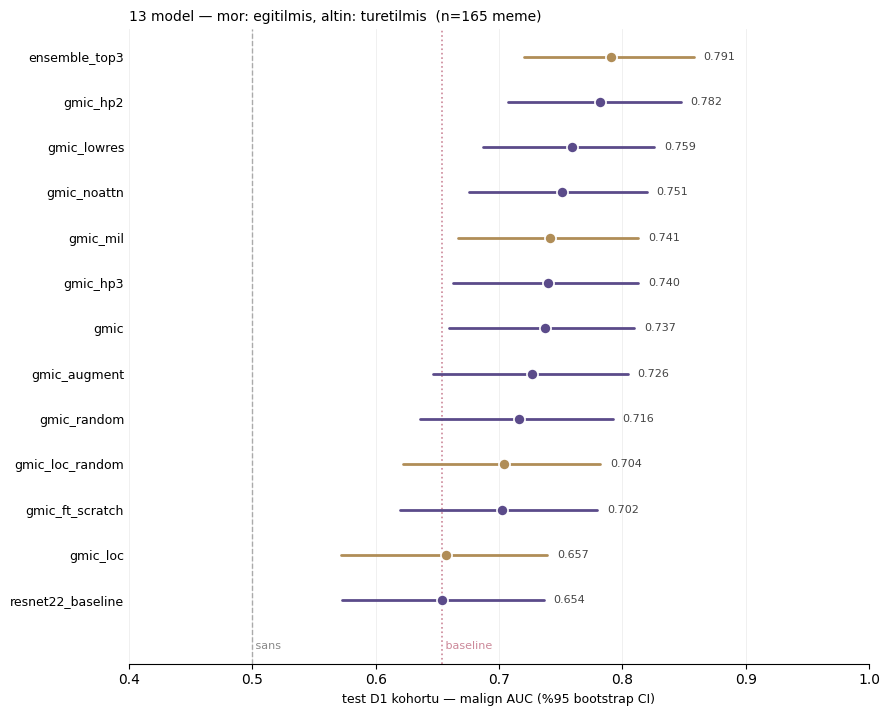

/content/drive/MyDrive/multiple_instance_classifier/degerlendirme/forest_auc.png


In [6]:
# --- Forest plot: AUC + %95 CI ---------------------------------------------------------
EGITILMIS_HUE = '#5B4B8A'
TURETILMIS_HUE = '#B08D57'   # renk tek basina kimlik tasimiyor; y eksenindeki isim tasiyor

d = KT.sort_values('auc')
fig, ax = plt.subplots(figsize=(9, 0.42 * len(d) + 1.8))
ref = KT[KT.model == 'resnet22_baseline'].auc.iloc[0]
ax.axvline(0.5, color='#AAAAAA', linewidth=1, linestyle='--', zorder=1)
ax.axvline(ref, color='#CC8899', linewidth=1.2, linestyle=':', zorder=1)

for i, r in enumerate(d.itertuples()):
    renk = TURETILMIS_HUE if r.tur == 'turetilmis' else EGITILMIS_HUE
    ax.plot([r.ci_alt, r.ci_ust], [i, i], color=renk, linewidth=2,
            solid_capstyle='round', zorder=3)
    ax.plot([r.auc], [i], 'o', color=renk, markersize=8,
            markeredgecolor='white', markeredgewidth=1.2, zorder=4)
    ax.text(r.ci_ust + 0.008, i, f'{r.auc:.3f}', va='center', fontsize=8, color='#444444')

ax.set_yticks(range(len(d)))
ax.set_yticklabels(d.model, fontsize=9)
ax.set_xlabel(f'test {KOHORT} kohortu — malign AUC (%95 bootstrap CI)', fontsize=9)
ax.set_xlim(0.40, 1.0)
ax.set_ylim(-1.4, len(d) - 0.4)
ax.grid(True, axis='x', alpha=0.22, linewidth=0.6)
ax.set_axisbelow(True)
for k in ['top', 'right', 'left']:
    ax.spines[k].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.text(0.5, -1.0, ' sans', fontsize=8, color='#888888', va='center')
ax.text(ref, -1.0, ' baseline', fontsize=8, color='#CC8899', va='center')
ax.set_title(f'{len(d)} model — mor: egitilmis, altin: turetilmis  (n={len(alt)} meme)',
             fontsize=10, loc='left')
fig.tight_layout()
FOREST = DEG_DIR / 'forest_auc.png'
fig.savefig(FOREST, dpi=150, bbox_inches='tight')
plt.show()
print(FOREST)

In [7]:
import zipfile
from pathlib import Path
from google.colab import files

K = Path('/content/drive/MyDrive/multiple_instance_classifier')
Z = Path('/content/rapor_paketi.zip')
ISTENEN = [
    'gmic/checkpoints/best.pt',
    'karsilastirma_ozeti.xlsx',
    'degerlendirme/karsilastirma_tablosu.xlsx',
    'degerlendirme/altgrup_tablosu.xlsx',
    'degerlendirme/forest_auc.png',
    'arama/secim.json',
    'arama/arama_ozeti.xlsx',
    'arama/arama_dagilim.png',
    'gmic/gmic_curves.png',
    'resnet22_baseline/resnet22_baseline_curves.png',
]
with zipfile.ZipFile(Z, 'w', zipfile.ZIP_DEFLATED) as z:
    for r in ISTENEN:
        p = K / r
        if p.exists():
            z.write(p, r)
            print(f'{p.stat().st_size/1e6:8.1f} MB  {r}')
        else:
            print(f'    YOK       {r}')
print(f'\n{Z}  ({Z.stat().st_size/1e6:.0f} MB)')
files.download(str(Z))


   169.5 MB  gmic/checkpoints/best.pt
     0.0 MB  karsilastirma_ozeti.xlsx
     0.0 MB  degerlendirme/karsilastirma_tablosu.xlsx
     0.0 MB  degerlendirme/altgrup_tablosu.xlsx
     0.1 MB  degerlendirme/forest_auc.png
     0.0 MB  arama/secim.json
     0.0 MB  arama/arama_ozeti.xlsx
     0.1 MB  arama/arama_dagilim.png
     0.3 MB  gmic/gmic_curves.png
     0.3 MB  resnet22_baseline/resnet22_baseline_curves.png

/content/rapor_paketi.zip  (156 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import shutil
shutil.copy('/content/rapor_paketi.zip',
            '/content/drive/MyDrive/multiple_instance_classifier/rapor_paketi.zip')
print('Drive\'a kopyalandi, arayuzden indirin')


Drive'a kopyalandi, arayuzden indirin
